In [ ]:
import os
import uuid

root = r"C:\Users\praya\Desktop\Custom Dataset\Videos"

for name in os.listdir(root):
    old_path = os.path.join(root, name)
    if not os.path.isdir(old_path):
        continue

    upper_name = name.upper()
    if name == upper_name:
        continue  # already uppercase

    # Step 1: rename to a temporary unique name
    tmp_name = f"__tmp__{uuid.uuid4().hex}__"
    tmp_path = os.path.join(root, tmp_name)

    os.rename(old_path, tmp_path)

    # Step 2: rename temp -> uppercase
    new_path = os.path.join(root, upper_name)
    os.rename(tmp_path, new_path)

    print(f"RENAMED: {name} -> {upper_name}")


In [ ]:
import os
import json
import csv
import time
import traceback
from collections import defaultdict

import cv2
import numpy as np
import mediapipe as mp


SEQUENCE_LENGTH = 30
MIN_SEQS_PER_WORD = 25 
TEST_SIZE = 0.2
SEED = 42
# =========================
# PATHS
# =========================
WORDS_TXT = r"D:\DATASET\final_100_words_min15.txt"
DATASET_JSON_PATH = r"D:\DATASET\WLASL_v0.3.json"
DATASET_VIDEOS_DIR = r"D:\DATASET\videos"

CUSTOM_DATASET_VIDEOS_DIR = r"C:\Users\praya\Desktop\Custom Dataset\Videos"
MP_DATA2 = r"C:\Users\praya\Desktop\Custom Dataset\MP_DATA2"

# =========================
# SETTINGS
# =========================
SEQUENCE_LENGTH = 30

KAGGLE_PER_WORD = 15
CUSTOM_PER_WORD = 10
TOTAL_PER_WORD = KAGGLE_PER_WORD + CUSTOM_PER_WORD  # 25

# No-face features:
# pose(33*4=132) + LH(21*3=63) + RH(21*3=63) = 258
EXPECTED_LEN = 258

VIDEO_EXTS = (".mp4", ".mov", ".avi", ".mkv", ".webm")
PRINT_EVERY_N_SEQS = 5

# =========================
# OUTPUT + LOGS
# =========================
LOG_DIR = os.path.join(MP_DATA2, "_logs")
os.makedirs(MP_DATA2, exist_ok=True)
os.makedirs(LOG_DIR, exist_ok=True)

INDEX_CSV = os.path.join(LOG_DIR, "index.csv")
ERROR_LOG = os.path.join(LOG_DIR, "errors.txt")

BUILDING A DATASET READY FOR EXTRACTION (ADDING CUSTOM DATASET AND KAGGLE DATASET)

In [ ]:
def log_error(msg: str):
    with open(ERROR_LOG, "a", encoding="utf-8") as f:
        f.write(msg.rstrip() + "\n")

# Prepare index.csv header if it doesn't exist
if not os.path.exists(INDEX_CSV):
    with open(INDEX_CSV, "w", newline="", encoding="utf-8") as f:
        w = csv.writer(f)
        w.writerow(["word", "seq_idx", "video_path", "source", "status"])

# =========================
# LOAD WORD LIST
# =========================
with open(WORDS_TXT, "r", encoding="utf-8") as f:
    actions = [w.strip().upper() for w in f if w.strip()]
actions_set = set(actions)

NONE_CLASS = "NONE"
if NONE_CLASS not in actions_set:
    actions.append(NONE_CLASS)
    actions_set.add(NONE_CLASS)

print("Requested words:", len(actions))

# =========================
# INDEX KAGGLE VIDEO FILES BY STEM
# =========================
video_files_by_stem = {}
for fn in os.listdir(DATASET_VIDEOS_DIR):
    if fn.lower().endswith(VIDEO_EXTS):
        stem = os.path.splitext(fn)[0]
        video_files_by_stem[stem] = os.path.join(DATASET_VIDEOS_DIR, fn)

# =========================
# BUILD KAGGLE WORD->VIDEOS
# =========================
with open(DATASET_JSON_PATH, "r", encoding="utf-8") as f:
    data = json.load(f)

kaggle_word_to_videos = defaultdict(list)

for entry in data:
    gloss = str(entry.get("gloss", "")).upper().strip()
    if gloss not in actions_set:
        continue

    for inst in entry.get("instances", []):
        vid = str(inst.get("video_id", "")).strip()
        if not vid:
            continue
        if vid in video_files_by_stem:
            kaggle_word_to_videos[gloss].append(video_files_by_stem[vid])

# unique + sort + cap 15
for w in list(kaggle_word_to_videos.keys()):
    kaggle_word_to_videos[w] = sorted(set(kaggle_word_to_videos[w]))[:KAGGLE_PER_WORD]

print("Words found in Kaggle JSON with local videos:", len(kaggle_word_to_videos))

# =========================
# BUILD CUSTOM WORD->VIDEOS
# =========================
custom_word_to_videos = defaultdict(list)

# Custom directory names might be uppercase already, but we handle case-insensitively:
custom_dirs = {d.upper(): os.path.join(CUSTOM_DATASET_VIDEOS_DIR, d)
               for d in os.listdir(CUSTOM_DATASET_VIDEOS_DIR)
               if os.path.isdir(os.path.join(CUSTOM_DATASET_VIDEOS_DIR, d))}

for w in actions:
    if w not in custom_dirs:
        continue
    wdir = custom_dirs[w]
    vids = []
    for fn in os.listdir(wdir):
        if fn.lower().endswith(VIDEO_EXTS):
            vids.append(os.path.join(wdir, fn))
    vids = sorted(vids)[:CUSTOM_PER_WORD]
    if vids:
        custom_word_to_videos[w] = vids

print("Words found in Custom videos:", len(custom_word_to_videos))

# =========================
# MERGE TO FINAL word_to_videos (25 each)
# =========================
word_to_videos = {}

for w in actions:
    kaggle_vids = kaggle_word_to_videos.get(w, [])
    custom_vids = custom_word_to_videos.get(w, [])
    
    # Special case for NONE: take 25 from custom only
    if w == NONE_CLASS:
        merged = custom_vids[:TOTAL_PER_WORD]   # 25
        if merged:
            word_to_videos[w] = merged
        continue
    

    merged = []
    # Take exact counts first
    merged.extend(kaggle_vids[:KAGGLE_PER_WORD])
    merged.extend(custom_vids[:CUSTOM_PER_WORD])

    # If either side is short, fill up to TOTAL_PER_WORD using whatever is available
    if len(merged) < TOTAL_PER_WORD:
        extras = kaggle_vids[KAGGLE_PER_WORD:] + custom_vids[CUSTOM_PER_WORD:]
        merged.extend(extras)

    # Final cap
    merged = merged[:TOTAL_PER_WORD]

    if merged:
        word_to_videos[w] = merged

print("Final words with any videos:", len(word_to_videos))
print("Example counts:", sorted([(w, len(v)) for w, v in word_to_videos.items()],
                               key=lambda x: x[1], reverse=True)[:10])


HELPER FUNCITONS

In [ ]:
# MEDIAPIPE HELPERS (NO FACE)
# =========================
mp_holistic = mp.solutions.holistic

def mediapipe_results(image_bgr, model):
    image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)
    image_rgb.flags.writeable = False
    results = model.process(image_rgb)
    image_rgb.flags.writeable = True
    return results


def extract_keypoints_no_face(results) -> np.ndarray:
    # Pose: 33*4 = 132
    if results.pose_landmarks:
        pose = np.array(
            [[lm.x, lm.y, lm.z, lm.visibility] for lm in results.pose_landmarks.landmark],
            dtype=np.float32
        ).flatten()
    else:
        pose = np.zeros(33 * 4, dtype=np.float32)

    # Left hand: 21*3 = 63
    if results.left_hand_landmarks:
        lh = np.array(
            [[lm.x, lm.y, lm.z] for lm in results.left_hand_landmarks.landmark],
            dtype=np.float32
        ).flatten()
    else:
        lh = np.zeros(21 * 3, dtype=np.float32)

    # Right hand: 21*3 = 63
    if results.right_hand_landmarks:
        rh = np.array(
            [[lm.x, lm.y, lm.z] for lm in results.right_hand_landmarks.landmark],
            dtype=np.float32
        ).flatten()
    else:
        rh = np.zeros(21 * 3, dtype=np.float32)

    out = np.concatenate([pose, lh, rh], axis=0)
    # Ensure exact length
    if out.shape[0] != EXPECTED_LEN:
        out = np.zeros(EXPECTED_LEN, dtype=np.float32)
    return out

def get_frame_indices(total_frames, n=30):
    if total_frames is None or total_frames <= 1:
        return None  # signal: use sequential read
    return np.linspace(0, total_frames - 1, n).astype(int).tolist()


def frame_file(seq_dir, i):
    return os.path.join(seq_dir, f"{i}.npy")

def sequence_complete(seq_dir, n=30):
    for i in range(n):
        p = frame_file(seq_dir, i)
        if (not os.path.exists(p)) or os.path.getsize(p) < 50:
            return False
    return True


MEDIAPIPE EXTRACTION

In [ ]:
# EXTRACTION LOOP
# =========================
total_seqs = sum(len(v) for v in word_to_videos.values())
done_seqs = 0
skipped_seqs = 0
failed_seqs = 0
t0 = time.time()

print(f"Total sequences planned: {total_seqs}")
print(f"Output MP_DATA2: {MP_DATA2}")
print(f"Expected feature length: {EXPECTED_LEN}")

with mp_holistic.Holistic(min_detection_confidence=0.5, min_tracking_confidence=0.5) as holistic:
    for word_i, (word, vids) in enumerate(word_to_videos.items(), start=1):
        word = word.upper()  # enforce uppercase output folders
        print(f"\n[{word_i}/{len(word_to_videos)}] WORD={word} clips={len(vids)}")

        for seq_idx, vp in enumerate(vids):
            try:
                source = "kaggle" if os.path.commonpath([vp, DATASET_VIDEOS_DIR]) == DATASET_VIDEOS_DIR else "custom"
            except Exception:
                source = "unknown"

            out_dir = os.path.join(MP_DATA2, word, str(seq_idx))

            # skip if already complete
            if sequence_complete(out_dir, SEQUENCE_LENGTH):
                skipped_seqs += 1
                if (seq_idx % PRINT_EVERY_N_SEQS) == 0:
                    print(f"  SKIP {word} #{seq_idx} ({os.path.basename(vp)})")
                with open(INDEX_CSV, "a", newline="", encoding="utf-8") as f:
                    csv.writer(f).writerow([word, seq_idx, vp, source, "SKIP_COMPLETE"])
                continue

            os.makedirs(out_dir, exist_ok=True)
            cap = None
            status = "OK"

            try:
                cap = cv2.VideoCapture(vp)
                if not cap.isOpened():
                    status = "FAIL_OPEN"
                    raise RuntimeError(f"Video cannot be opened: {vp}")

                total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
                frame_ids = get_frame_indices(total_frames, SEQUENCE_LENGTH)

                if frame_ids is None:
                    # Fallback: sequential read (for videos with unknown frame count)
                    for i in range(SEQUENCE_LENGTH):
                        out_npy = frame_file(out_dir, i)

                        if os.path.exists(out_npy) and os.path.getsize(out_npy) >= 50:
                            continue

                        ret, frame = cap.read()
                        if not ret or frame is None:
                            np.save(out_npy, np.zeros(EXPECTED_LEN, dtype=np.float32))
                            continue

                        results = mediapipe_results(frame, holistic)
                        keypoints = extract_keypoints_no_face(results)
                        np.save(out_npy, keypoints.astype(np.float32))

                else:
                    # Normal: random-access using frame indices
                    for i, fid in enumerate(frame_ids):
                        out_npy = frame_file(out_dir, i)

                        if os.path.exists(out_npy) and os.path.getsize(out_npy) >= 50:
                            continue

                        cap.set(cv2.CAP_PROP_POS_FRAMES, int(fid))
                        ret, frame = cap.read()

                        if not ret or frame is None:
                            np.save(out_npy, np.zeros(EXPECTED_LEN, dtype=np.float32))
                            continue

                        results = mediapipe_results(frame, holistic)
                        keypoints = extract_keypoints_no_face(results)
                        np.save(out_npy, keypoints.astype(np.float32))

                # final check
                if not sequence_complete(out_dir, SEQUENCE_LENGTH):
                    status = "INCOMPLETE"
                    raise RuntimeError(f"Sequence incomplete after extraction: {out_dir}")

                done_seqs += 1
                if (seq_idx % PRINT_EVERY_N_SEQS) == 0:
                    elapsed = time.time() - t0
                    rate = (done_seqs + skipped_seqs) / max(elapsed, 1e-6)
                    print(
                        f"  DO   {word} #{seq_idx} ({os.path.basename(vp)}) | "
                        f"done={done_seqs} skip={skipped_seqs} fail={failed_seqs} | {rate:.2f} seq/s"
                    )

            except Exception as e:
                failed_seqs += 1
                status = status if status != "OK" else "ERROR"

                err = (
                    f"[{word} #{seq_idx}] {status}\n"
                    f"video: {vp}\n"
                    f"out:   {out_dir}\n"
                    f"err:   {repr(e)}\n"
                    f"{traceback.format_exc()}\n"
                    f"{'-'*60}"
                )
                log_error(err)
                print(f"  FAIL {word} #{seq_idx} ({os.path.basename(vp)}) -> {status}")

            finally:
                if cap is not None:
                    cap.release()

            with open(INDEX_CSV, "a", newline="", encoding="utf-8") as f:
                csv.writer(f).writerow([word, seq_idx, vp, source, status])

elapsed = time.time() - t0
print("\nDone ")
print(f"Total: done={done_seqs} skip={skipped_seqs} fail={failed_seqs} out of {total_seqs}")
print(f"Elapsed: {elapsed/60:.2f} minutes")
print(f"Index: {INDEX_CSV}")
print(f"Errors: {ERROR_LOG}")

Build X, y_labels, usable_words, label_map from MP_DATA2

In [ ]:
import os
import numpy as np
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split




def load_sequence(seq_dir, n=30, expected_len=258):
    frames = []
    for i in range(n):
        p = os.path.join(seq_dir, f"{i}.npy")
        arr = np.load(p).astype(np.float32).reshape(-1)

        # hard-fix unexpected shapes
        if arr.shape[0] != expected_len:
            fixed = np.zeros(expected_len, dtype=np.float32)
            fixed[:min(expected_len, arr.shape[0])] = arr[:min(expected_len, arr.shape[0])]
            arr = fixed

        frames.append(arr)

    return np.stack(frames, axis=0)  # (n, expected_len)


# 1) Collect labels (folders)
labels = []
for name in os.listdir(MP_DATA2):
    p = os.path.join(MP_DATA2, name)
    if os.path.isdir(p) and name not in ["_logs"]:
        labels.append(name.upper())

labels = sorted(set(labels))
print("Labels found:", len(labels), labels[:10])

# 2) Collect sequence directories per label
word_seq_dirs = {}
for w in labels:
    wdir = os.path.join(MP_DATA2, w)
    if not os.path.isdir(wdir):
        # in case folder is not uppercase physically
        # try case-insensitive match:
        matches = [d for d in os.listdir(MP_DATA2) if d.upper() == w]
        if matches:
            wdir = os.path.join(MP_DATA2, matches[0])

    seqs = []
    for s in os.listdir(wdir):
        sp = os.path.join(wdir, s)
        if os.path.isdir(sp):
            # must contain 0..29.npy
            ok = True
            for i in range(SEQUENCE_LENGTH):
                if not os.path.exists(os.path.join(sp, f"{i}.npy")):
                    ok = False
                    break
            if ok:
                seqs.append(sp)

    seqs = sorted(seqs)
    if len(seqs) >= MIN_SEQS_PER_WORD:
        word_seq_dirs[w] = seqs[:MIN_SEQS_PER_WORD]  # exactly 25

usable_words = sorted(word_seq_dirs.keys())
print("Usable words:", len(usable_words))
print("Min seqs per word:", min(len(word_seq_dirs[w]) for w in usable_words))
print(usable_words)

# 3) Build label map
label_map = {w: i for i, w in enumerate(usable_words)}

# 4) Load X and y_labels
X_list, y_labels = [], []

for w in usable_words:
    for seq_dir in word_seq_dirs[w]:
        X_list.append(load_sequence(seq_dir, SEQUENCE_LENGTH, EXPECTED_LEN))
        y_labels.append(label_map[w])

X = np.asarray(X_list, dtype=np.float32)   # (N,30,258)
y_int = np.asarray(y_labels, dtype=np.int64)
y = to_categorical(y_int, num_classes=len(usable_words)).astype(np.float32)

print("X:", X.shape, "y:", y.shape)





NORMALIZE, SPLIT 

In [ ]:
# 5) Normalize (per-sample)
X = (X - X.mean(axis=(1, 2), keepdims=True)) / (X.std(axis=(1, 2), keepdims=True) + 1e-6)

# 6) Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=TEST_SIZE,
    random_state=SEED,
    stratify=y_int
)

print("Train:", X_train.shape, y_train.shape)
print("Test :", X_test.shape, y_test.shape)


NUM_CLASSES = y_train.shape[1]   # = 99
SEQ_LEN = X_train.shape[1]       # = 30
FEATS = X_train.shape[2]         # = 258
print("NUM_CLASSES:", NUM_CLASSES, "SEQ_LEN:", SEQ_LEN, "FEATS:", FEATS)

CNN MODEl

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv1D, BatchNormalization, Dropout, GlobalAveragePooling1D, Dense
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

inputs = Input(shape=(SEQ_LEN, FEATS))

x = Conv1D(128, 3, padding="same", activation="relu")(inputs)
x = BatchNormalization()(x)

x = Conv1D(256, 3, padding="same", activation="relu")(x)
x = BatchNormalization()(x)
x = Dropout(0.3)(x)

x = Conv1D(256, 3, padding="same", activation="relu")(x)
x = BatchNormalization()(x)

x = GlobalAveragePooling1D()(x)

x = Dense(256, activation="relu")(x)
x = Dropout(0.4)(x)

outputs = Dense(NUM_CLASSES, activation="softmax")(x)

model = Model(inputs, outputs)
model.summary()





Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 30, 258)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_3 (Conv1D)   │ (None, 30, 128)   │     99,200 │ input_layer_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 30, 128)   │        512 │ conv1d_3[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ spatial_dropout1d_2 │ (None, 30, 128)   │          0 │ batch_normalizat… │
│ (SpatialDropout1D)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_4 (Conv1D)   │ (None, 30, 256)   │     98,560 │ spatial_dropout1… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 30, 256)   │      1,024 │ conv1d_4[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ spatial_dropout1d_3 │ (None, 30, 256)   │          0 │ batch_normalizat… │
│ (SpatialDropout1D)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_5 (Conv1D)   │ (None, 30, 256)   │    196,864 │ spatial_dropout1… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 30, 256)   │      1,024 │ conv1d_5[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 256)       │          0 │ batch_normalizat… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 256)       │          0 │ batch_normalizat… │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 512)       │          0 │ global_average_p… │
│ (Concatenate)       │                   │            │ global_max_pooli… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 256)       │    131,328 │ concatenate_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 256)       │          0 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 99)        │     25,443 │ dropout_1[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 553,955 (2.11 MB)

 Trainable params: 552,675 (2.11 MB)

 Non-trainable params: 1,280 (5.00 KB)

MODEL COMPILATION

In [17]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss="categorical_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.TopKCategoricalAccuracy(k=5, name="top5_acc")
    ]
)


TRAIN

In [18]:
SAVE_DIR = r"C:\Users\praya\Desktop\Custom Dataset"
MODEL_OUT = os.path.join(SAVE_DIR, "asl_cnn_nofacenew.keras")
LABELS_OUT = os.path.join(SAVE_DIR, "class_names_nofacenew.json")

callbacks = [
    ModelCheckpoint(MODEL_OUT, monitor="val_accuracy", save_best_only=True, verbose=1),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=4, min_lr=1e-6, verbose=1),
    EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True, verbose=1),
]

history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=80,
    batch_size=32,
    callbacks=callbacks
)


Epoch 1/80
91/93 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.0147 - loss: 5.1239 - top5_acc: 0.0735
Epoch 1: val_accuracy improved from None to 0.03030, saving model to C:\Users\praya\Desktop\Custom Dataset\asl_cnn_nofacenew.keras
93/93 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - accuracy: 0.0175 - loss: 4.7741 - top5_acc: 0.0865 - val_accuracy: 0.0303 - val_loss: 4.5513 - val_top5_acc: 0.0970 - learning_rate: 0.0010
Epoch 2/80
92/93 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.0353 - loss: 4.4003 - top5_acc: 0.1420
Epoch 2: val_accuracy improved from 0.03030 to 0.06667, saving model to C:\Users\praya\Desktop\Custom Dataset\asl_cnn_nofacenew.keras
93/93 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.0391 - loss: 4.3519 - top5_acc: 0.1529 - val_accuracy: 0.0667 - val_loss: 4.1194 - val_top5_acc: 0.2202 - learning_rate: 0.0010
Epoch 3/80
92/93 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.0708 - loss: 4.1011 - top5_acc: 0.2126
Epoch 3: val_accuracy did not improve from 0.06667
93/93 ━━

In [19]:
import os, json

SAVE_DIR = r"C:\Users\praya\Desktop\Custom Dataset"
os.makedirs(SAVE_DIR, exist_ok=True)

FINAL_MODEL_PATH  = os.path.join(SAVE_DIR, "asl_cnn_final_nofacenew.keras")
CLASS_NAMES_PATH  = os.path.join(SAVE_DIR, "class_names_nofacenew.json")
HISTORY_PATH      = os.path.join(SAVE_DIR, "history_nofacenew.json")

# -------------------------
# 1) Class names (MUST match training order)
# -------------------------
if "usable_words" in globals() and usable_words and len(usable_words) > 0:
    class_names = list(usable_words)
elif "class_names" in globals() and class_names and len(class_names) > 0:
    class_names = list(class_names)
else:
    raise RuntimeError("usable_words/class_names not found. Save labels from the same notebook where you trained.")

# -------------------------
# 2) Sanity check: model outputs == label count
# -------------------------
num_classes_model = int(model.output_shape[-1])
num_classes_labels = len(class_names)

print("Model classes :", num_classes_model)
print("Label classes :", num_classes_labels)

if num_classes_model != num_classes_labels:
    raise ValueError(
        f"Mismatch: model outputs {num_classes_model} classes but labels JSON has {num_classes_labels}. "
        "Save class_names from the SAME usable_words used in training."
    )

# Optional: warn if NONE missing
if "NONE" not in [c.upper() for c in class_names]:
    print("WARNING: 'NONE' not found in labels. App may hallucinate when no sign is present.")

# -------------------------
# 3) Save model
# -------------------------
model.save(FINAL_MODEL_PATH)
print("Saved final model →", FINAL_MODEL_PATH)

# -------------------------
# 4) Save training history
# -------------------------
if "history" in globals() and history is not None:
    with open(HISTORY_PATH, "w", encoding="utf-8") as f:
        json.dump(history.history, f, indent=2)
    print("Saved history →", HISTORY_PATH)
else:
    print("WARNING: history not found, skipping history save.")

# -------------------------
# 5) Save class names
# -------------------------
with open(CLASS_NAMES_PATH, "w", encoding="utf-8") as f:
    json.dump(class_names, f, indent=2)

print("Saved class names →", CLASS_NAMES_PATH)


Model classes : 99
Label classes : 99
Saved final model → C:\Users\praya\Desktop\Custom Dataset\asl_cnn_final_nofacenew.keras
Saved history → C:\Users\praya\Desktop\Custom Dataset\history_nofacenew.json
Saved class names → C:\Users\praya\Desktop\Custom Dataset\class_names_nofacenew.json


              precision    recall  f1-score   support

    ACCIDENT      1.000     0.600     0.750         5
       AGAIN      0.833     1.000     0.909         5
         ALL      1.000     0.600     0.750         5
       APPLE      0.667     0.800     0.727         5
         BAD      0.667     0.400     0.500         5
         BED      0.429     0.600     0.500         5
      BEFORE      0.800     0.800     0.800         5
        BIRD      0.600     0.600     0.600         5
       BLACK      0.667     0.800     0.727         5
        BLUE      0.600     0.600     0.600         5
        BOOK      1.000     0.400     0.571         5
     BOWLING      1.000     1.000     1.000         5
         BUY      0.500     0.600     0.545         5
        CALL      0.667     0.400     0.500         5
         CAN      0.714     1.000     0.833         5
       CANDY      0.667     0.800     0.727         5
       CHAIR      0.600     0.600     0.600         5
      CHANGE      0.455    

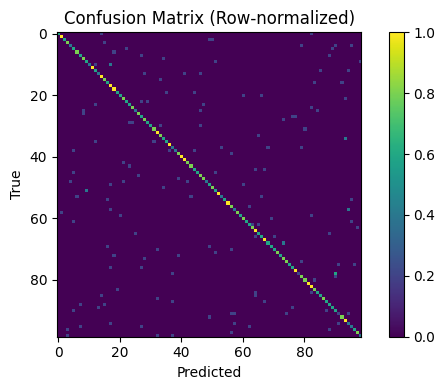


Top confusions:
THANKSGIVING → WOMAN : 3
MAKE → YEAR : 2
BOOK → CHANGE : 2
EAT → WRONG : 2
READ → STUDY : 2
KNOW → BLUE : 2
DOCTOR → TIME : 1
WORK → MAKE : 1
YES → BIRD : 1
YOUR → APPLE : 1
PLAY → NOW : 1
NO → YOU : 1
TALL → COW : 1
CHAIR → WALK : 1
TABLE → THIN : 1

Top-1 Accuracy: 0.695
Top-5 Accuracy: 0.883


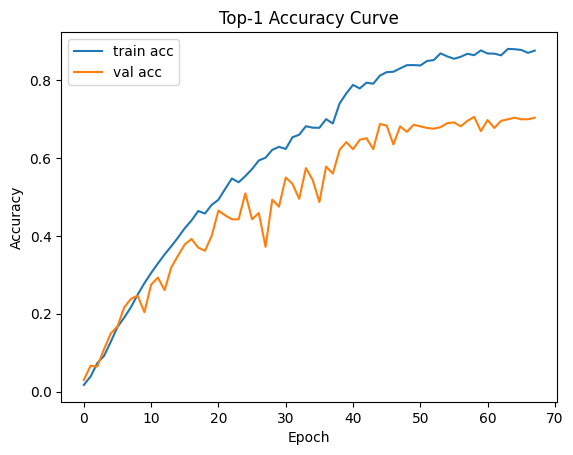

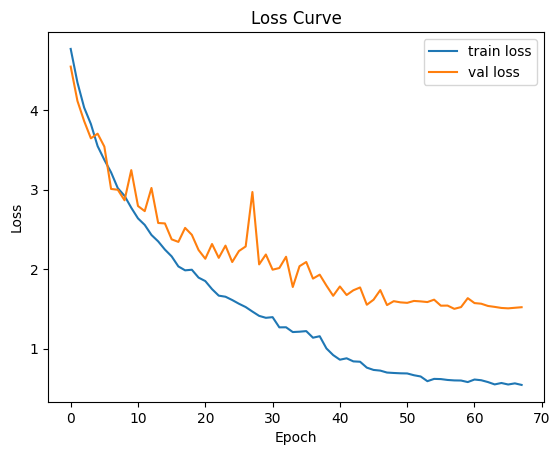

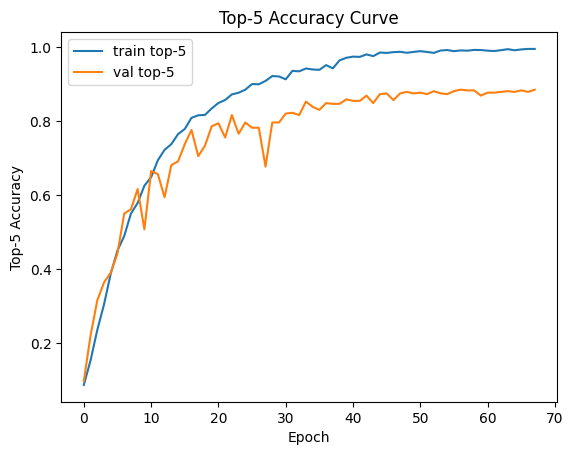

In [20]:
# VISUALIZATION (UPDATED)
# =========================
import os, json, numpy as np, matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report
from collections import Counter

SAVE_DIR = r"C:\Users\praya\Desktop\Custom Dataset"
CLASS_NAMES_PATH = os.path.join(SAVE_DIR, "class_names_nofacenew.json")

# Load labels
with open(CLASS_NAMES_PATH, "r") as f:
    class_names = json.load(f)

num_classes = len(class_names)

# Predictions
y_true = np.argmax(y_test, axis=1)
y_prob = model.predict(X_test, verbose=0)
y_pred = np.argmax(y_prob, axis=1)

# =========================
# 1) CLASSIFICATION REPORT (OPTIONAL)
# =========================
# With many classes, this is noisy.
# Use mainly for debugging, not performance judgment.
print(
    classification_report(
        y_true,
        y_pred,
        target_names=class_names,
        digits=3,
        zero_division=0
    )
)

# =========================
# 2) CONFUSION MATRIX (NORMALIZED)
# =========================
cm = confusion_matrix(y_true, y_pred)
cm_norm = cm / np.maximum(cm.sum(axis=1, keepdims=True), 1)

plt.figure(figsize=(6, 4))
plt.imshow(cm_norm, interpolation="nearest")
plt.title("Confusion Matrix (Row-normalized)")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.colorbar(fraction=0.046)
plt.tight_layout()
plt.show()

# =========================
# 3) TOP CONFUSIONS (MOST USEFUL)
# =========================
errors = [(t, p) for t, p in zip(y_true, y_pred) if t != p]

print("\nTop confusions:")
for (t, p), cnt in Counter(errors).most_common(15):
    print(f"{class_names[t]} → {class_names[p]} : {cnt}")

# =========================
# 4) TOP-K ACCURACY (CRITICAL METRIC)
# =========================
top5_correct = 0
for i in range(len(y_true)):
    if y_true[i] in np.argsort(y_prob[i])[-5:]:
        top5_correct += 1

top5_acc = top5_correct / len(y_true)
top1_acc = np.mean(y_true == y_pred)

print(f"\nTop-1 Accuracy: {top1_acc:.3f}")
print(f"Top-5 Accuracy: {top5_acc:.3f}")

# =========================
# 5) TRAINING CURVES (UPDATED)
# =========================
plt.figure()
plt.plot(history.history["accuracy"], label="train acc")
plt.plot(history.history["val_accuracy"], label="val acc")
plt.legend()
plt.title("Top-1 Accuracy Curve")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.show()

plt.figure()
plt.plot(history.history["loss"], label="train loss")
plt.plot(history.history["val_loss"], label="val loss")
plt.legend()
plt.title("Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

# Optional: Top-5 curve if logged
if "top5_acc" in history.history:
    plt.figure()
    plt.plot(history.history["top5_acc"], label="train top-5")
    plt.plot(history.history["val_top5_acc"], label="val top-5")
    plt.legend()
    plt.title("Top-5 Accuracy Curve")
    plt.xlabel("Epoch")
    plt.ylabel("Top-5 Accuracy")
    plt.show()


In [ ]:
import json
import numpy as np
import tensorflow as tf

MODEL_PATH  = r"C:\Users\praya\Desktop\Custom Dataset\asl_cnn_final_noface.keras"
LABELS_PATH = r"C:\Users\praya\Desktop\Custom Dataset\class_names_noface.json"

# Load model
model = tf.keras.models.load_model(MODEL_PATH, compile=False)

# Load labels
with open(LABELS_PATH, "r", encoding="utf-8") as f:
    labels = json.load(f)

print("Model loaded ")
print("Model output classes:", model.output_shape[-1])
print("Labels:", len(labels))

# Make a dummy sequence (30 frames, 258 features) like your no-face input
X = np.zeros((1, 30, 258), dtype=np.float32)

# Predict
probs = model.predict(X, verbose=0)[0]
idx = int(np.argmax(probs))
conf = float(probs[idx])

print("Top prediction:", labels[idx])
print("Confidence:", conf)
print("Top-5:")
top5 = np.argsort(probs)[-5:][::-1]
for i in top5:
    print(f"  {labels[i]} : {probs[i]:.4f}")
